<a href="https://colab.research.google.com/github/hyperpipe-kr/colab-examples/blob/main/08_LangGraph_mail_sorting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 알프레드 이메일 분류 시스템: A LangGraph Example

알프레드 이메일 분류 시스템을 구현할 것입니다. 알프레드는 다음과 같은 작업을 수행해야 합니다:

- 들어오는 이메일 읽기
- 스팸 또는 정상 메일로 분류하기
- 정상 메일에 대한 임시 답장 작성하기
- 정상 메일일 경우 Mr. Hugg 정보 전달(출력만)

이 예제는 LLM 기반 의사결정을 포함하는 LangGraph 워크플로우를 어떻게 구조화할 수 있는지를 보여줍니다. (여기서는 별도의 툴이 사용되지 않으므로 Agent라고 부르진 않지만, LangGraph 프레임워크 학습에 초점을 둡니다.)

![flowchart](https://huggingface.co/datasets/agents-course/course-images/resolve/main/en/unit2/LangGraph/first_graph.png)


In [1]:
# Install the required packages
%pip install -q langgraph langchain_openai langchain_huggingface

## 환경 설정

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
!pip install python-dotenv

In [ ]:
from dotenv import load_dotenv
load_dotenv('/content/drive/MyDrive/lg-dx/env', override=True)

import os
openai_api_key = os.environ.get('OPENAI_API_KEY')
print("openai_api_key : " + openai_api_key)
langchain_api_key = os.environ.get('LANGCHAIN_API_KEY')
print("langchain_api_key : " + langchain_api_key)

In [5]:
import os
from typing import TypedDict, List, Dict, Any, Optional
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage

# Initialize our LLM
model = ChatOpenAI(model="gpt-5.4-mini", temperature=0)

## 1단계: 상태(State) 정의하기

이메일 처리 워크플로우에서 알프레드가 추적해야 할 정보를 정의합니다

In [6]:
class EmailState(TypedDict):
    # 처리 중인 이메일
    email: Dict[str, Any]  # 제목, 발신자, 본문 등 포함

    # 이메일 분류(문의, 불만 등)
    email_category: Optional[str]

    # 스팸으로 분류된 이유
    spam_reason: Optional[str]

    # 분석 및 결정
    is_spam: Optional[bool]

    # 답장 생성
    email_draft: Optional[str]

    # 처리 메타데이터
    messages: List[Dict[str, Any]]  # LLM과의 대화 추적

## 2단계: 노드 정의하기

In [7]:
def read_email(state: EmailState):
    """알프레드가 들어온 이메일을 읽고 기록합니다."""
    email = state["email"]
    print(f"알프레드가 {email['sender']}로부터 온 메일(제목: {email['subject']})을 처리 중입니다.")
    return {}

import json

def classify_email(state: EmailState):
    """알프레드가 LLM을 사용해 이메일을 스팸/정상으로 분류합니다."""
    email = state["email"]

    prompt = f"""
    집사 알프레드로서, 이 이메일을 분석해 스팸인지 정상인지 판단하세요.

    이메일:
    From: {email['sender']}
    Subject: {email['subject']}
    Body: {email['body']}

    아래 JSON 형식으로만 응답하세요. 다른 설명이나 마크다운 백틱은 절대 포함하지 마세요.
    {{
      "is_spam": true 또는 false,
      "spam_reason": "스팸인 경우 그 이유 (정상 메일이면 null)",
      "category": "정상 메일인 경우 inquiry/complaint/thank you/request/information 중 하나 (스팸이면 null)"
    }}
    """

    messages = [HumanMessage(content=prompt)]
    response = model.invoke(messages)

    # JSON 파싱 (마크다운 코드펜스가 붙어올 경우 대비)
    raw = response.content.strip()
    if raw.startswith("```"):
        raw = raw.strip("`")
        raw = raw[raw.find("{"):raw.rfind("}") + 1]

    try:
        result = json.loads(raw)
        is_spam = bool(result.get("is_spam", False))
        spam_reason = result.get("spam_reason") if is_spam else None
        email_category = result.get("category") if not is_spam else None
    except json.JSONDecodeError:
        # 파싱 실패 시 안전하게 폴백 (한/영 키워드 모두 확인)
        text = response.content.lower()
        is_spam = ("스팸" in text or "spam" in text) and \
                  ("스팸이 아" not in text and "not spam" not in text)
        spam_reason = response.content if is_spam else None
        email_category = None

    new_messages = state.get("messages", []) + [
        {"role": "user", "content": prompt},
        {"role": "assistant", "content": response.content}
    ]

    return {
        "is_spam": is_spam,
        "spam_reason": spam_reason,
        "email_category": email_category,
        "messages": new_messages
    }

def handle_spam(state: EmailState):
    """알프레드가 스팸 메일을 처리합니다."""
    print(f"알프레드는 이 메일을 스팸으로 분류했습니다. 이유: {state['spam_reason']}")
    print("이 메일은 스팸 폴더로 이동되었습니다.")
    return {}

def draft_response(state: EmailState):
    """알프레드가 정상 메일에 임시 답장을 작성합니다."""
    email = state["email"]
    category = state["email_category"] or "일반"
    prompt = f"""
    집사 알프레드로서, 이 이메일에 정중한 임시 답장을 작성하세요.

    이메일:
    From: {email['sender']}
    Subject: {email['subject']}
    Body: {email['body']}

    이 이메일의 카테고리: {category}

    Mr. Hugg가 검토 후 개인화할 수 있도록 간단하고 전문적인 답장을 작성하세요.
    """
    messages = [HumanMessage(content=prompt)]
    response = model.invoke(messages)
    new_messages = state.get("messages", []) + [
        {"role": "user", "content": prompt},
        {"role": "assistant", "content": response.content}
    ]
    return {
        "email_draft": response.content,
        "messages": new_messages
    }

def notify_mr_hugg(state: EmailState):
    """알프레드가 Mr. Hugg에게 메일과 임시 답장을 전달합니다."""
    email = state["email"]
    print("\n" + "="*50)
    print(f"주인님, {email['sender']}로부터 메일이 도착했습니다.")
    print(f"제목: {email['subject']}")
    print(f"카테고리: {state['email_category']}")
    print("\n검토하실 임시 답장을 준비했습니다:")
    print("-"*50)
    print(state["email_draft"])
    print("="*50 + "\n")
    return {}

## 3단계: 분기 로직 정의하기
분류 후 어떤 경로로 갈지 결정하는 함수를 만듭니다.

💡 참고: 이 라우팅 함수는 LangGraph가 분류 노드 이후 어떤 엣지를 따라갈지 결정할 때 호출됩니다. 반환값은 조건부 엣지 매핑의 키와 일치해야 합니다.

In [8]:
def route_email(state: EmailState) -> str:
    """스팸 분류 결과에 따라 다음 단계를 결정합니다."""
    if state["is_spam"]:
        return "spam"
    else:
        return "legitimate"

## 4단계: StateGraph 생성 및 엣지 정의

In [9]:
# 그래프 생성
email_graph = StateGraph(EmailState)

# 노드 추가
email_graph.add_node("read_email", read_email)
email_graph.add_node("classify_email", classify_email)
email_graph.add_node("handle_spam", handle_spam)
email_graph.add_node("draft_response", draft_response)
email_graph.add_node("notify_mr_hugg", notify_mr_hugg)

# 엣지 시작
email_graph.add_edge(START, "read_email")
# 흐름 정의
email_graph.add_edge("read_email", "classify_email")

# 분기 추가
email_graph.add_conditional_edges(
    "classify_email",
    route_email,
    {
        "spam": "handle_spam",
        "legitimate": "draft_response"
    }
)

# 마지막 엣지
email_graph.add_edge("handle_spam", END)
email_graph.add_edge("draft_response", "notify_mr_hugg")
email_graph.add_edge("notify_mr_hugg", END)

# 그래프 컴파일
compiled_graph = email_graph.compile()


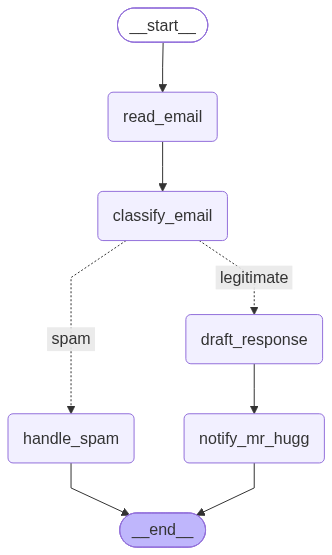

In [10]:
from IPython.display import Image, display

display(Image(compiled_graph.get_graph().draw_mermaid_png()))

## 5단계: 어플리케이션 실행하기
정상 메일과 스팸 메일로 그래프를 테스트해봅니다:

In [27]:
# 정상 메일 예시
email_exam_1 = {
    "sender": "john.smith@example.com",
    "subject": "서비스 문의",
    "body": "안녕하세요 Mr. Hugg, 동료의 추천으로 연락드립니다. 귀하의 컨설팅 서비스에 대해 더 알고 싶습니다. 다음 주에 통화 가능할까요? 감사합니다, John Smith"
}

# 스팸 메일 예시
email_exam_2 = {
    "sender": "winner@lottery-intl.com",
    "subject": "당신은 $5,000,000에 당첨되었습니다!!!",
    "body": "축하합니다! 국제 복권에 당첨되셨습니다! 상금을 받으시려면 은행 정보와 수수료 $100을 보내주세요."
}

# 정상 메일 처리
print("\n정상 메일 처리 중...")
legitimate_result = compiled_graph.invoke({
    "email": email_exam_1,
    "is_spam": None,
    "spam_reason": None,
    "email_category": None,
    "email_draft": None,
    "messages": []
})

# 스팸 메일 처리
print("\n스팸 메일 처리 중...")
spam_result = compiled_graph.invoke({
    "email": email_exam_2,
    "is_spam": None,
    "spam_reason": None,
    "email_category": None,
    "email_draft": None,
    "messages": []
})


정상 메일 처리 중...
알프레드가 john.smith@example.com로부터 온 메일(제목: 서비스 문의)을 처리 중입니다.

주인님, john.smith@example.com로부터 메일이 도착했습니다.
제목: 서비스 문의
카테고리: inquiry

검토하실 임시 답장을 준비했습니다:
--------------------------------------------------
물론입니다. 아래는 Mr. Hugg께서 검토 후 개인화하실 수 있는, 정중하고 전문적인 임시 답장입니다.

---

제목: Re: 서비스 문의

안녕하세요 John Smith님,

연락 주셔서 감사합니다. 동료분의 추천을 통해 문의 주셨다니 반갑습니다.

컨설팅 서비스에 대해 관심 가져 주셔서 감사드리며, 다음 주에 통화하는 것도 가능합니다. 편하신 날짜와 시간을 몇 가지 알려주시면 일정을 조율하겠습니다.

곧 말씀 나눌 수 있기를 바랍니다.

감사합니다,  
Alfred  
집사 드림

---

원하시면 제가 더 격식 있는 버전이나 더 따뜻한 톤으로도 바꿔드릴 수 있습니다.


스팸 메일 처리 중...
알프레드가 winner@lottery-intl.com로부터 온 메일(제목: 당신은 $5,000,000에 당첨되었습니다!!!)을 처리 중입니다.
알프레드는 이 메일을 스팸으로 분류했습니다. 이유: 국제 복권 당첨을 가장해 거액의 상금을 미끼로 개인정보와 선입금을 요구하는 전형적인 스팸/사기 이메일입니다.
이 메일은 스팸 폴더로 이동되었습니다.


## 6단계: Langfuse로 메일 분류 에이전트 관찰하기 📡

알프레드는 메일 분류 에이전트를 다듬으면서 디버깅에 지쳐갑니다. 에이전트는 본질적으로 예측 불가능하고 추적이 어렵기 때문입니다. 하지만 궁극의 스팸 감지 에이전트를 만들어 프로덕션에 배포하려면, 향후 모니터링과 분석을 위한 강력한 추적 기능이 필요합니다.

이를 위해 알프레드는 Langfuse와 같은 관찰 도구를 사용할 수 있습니다.

먼저 Langfuse를 설치합니다:

In [12]:
%pip install -q langfuse

Next, we set the Langfuse API keys and host address as environment variables. You can get your Langfuse credentials by signing up for [Langfuse Cloud](https://cloud.langfuse.com) or [self-hosting Langfuse](https://langfuse.com/self-hosting).

In [24]:
import os

# Get keys for your project from the project settings page: https://cloud.langfuse.com
os.environ["LANGFUSE_PUBLIC_KEY"] = "pk-..."
os.environ["LANGFUSE_SECRET_KEY"] = "sk-..."
os.environ["LANGFUSE_HOST"] = "https://jp.cloud.langfuse.com"

Now, we configure the [Langfuse `callback_handler`](https://langfuse.com/docs/integrations/langchain/tracing#add-langfuse-to-your-langchain-application).

In [25]:
from langfuse.langchain import CallbackHandler

# Initialize Langfuse CallbackHandler for LangGraph/Langchain (tracing)
langfuse_handler = CallbackHandler()

We then add `config={"callbacks": [langfuse_handler]}` to the invocation of the agents and run them again.

In [26]:
# Process legitimate email
print("\nProcessing legitimate email...")
legitimate_result = compiled_graph.invoke(
    input={
        "email": email_exam_1,
        "is_spam": None,
        "draft_response": None,
        "messages": []
    },
    config={"callbacks": [langfuse_handler]}
)

# Process spam email
print("\nProcessing spam email...")
spam_result = compiled_graph.invoke(
    input={
        "email": email_exam_2,
        "is_spam": None,
        "draft_response": None,
        "messages": []
    },
    config={"callbacks": [langfuse_handler]}
)


Processing legitimate email...
알프레드가 john.smith@example.com로부터 온 메일(제목: 서비스 문의)을 처리 중입니다.

주인님, john.smith@example.com로부터 메일이 도착했습니다.
제목: 서비스 문의
카테고리: inquiry

검토하실 임시 답장을 준비했습니다:
--------------------------------------------------
물론입니다. 아래는 Mr. Hugg께서 검토 후 쉽게 개인화하실 수 있는 간단하고 전문적인 임시 답장입니다.

---

제목: Re: 서비스 문의

안녕하세요 John Smith님,

연락 주셔서 감사합니다. 동료분의 추천까지 더해져 더욱 반갑습니다. 저희 컨설팅 서비스에 관심을 가져 주셔서 감사드립니다.

다음 주에 통화 가능합니다. 편하신 날짜와 시간을 몇 가지 알려주시면 일정 조율해 보겠습니다.

감사합니다.  
Alfred  
(대리 작성)

---

원하시면 제가 더 격식 있는 버전이나 좀 더 따뜻한 톤으로도 바꿔드릴 수 있습니다.


Processing spam email...
알프레드가 winner@lottery-intl.com로부터 온 메일(제목: 당신은 $5,000,000에 당첨되었습니다!!!)을 처리 중입니다.
알프레드는 이 메일을 스팸으로 분류했습니다. 이유: 국제 복권 당첨을 가장하며 거액의 상금을 미끼로 은행 정보와 선불 수수료 $100을 요구하는 전형적인 피싱/사기성 스팸입니다.
이 메일은 스팸 폴더로 이동되었습니다.
